# Hallucination Evaluation
**Query Expansion Study — Dahl et al. (2024) methodology**

Three conditions:
- **C0 baseline** — raw queries, no expansion
- **C1 structured** — task-specific scaffolding prepended
- **C2 premise** — false-premise rejection, fake_* tasks only

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Import scoring logic from evaluate.py — single source of truth
sys.path.insert(0, str(Path(".").resolve()))
from evaluate import score_record, REFUSAL_SCORE, HALL_THRESHOLD

sns.set_theme(style="whitegrid", font_scale=1.05)
RESULTS_DIR = Path("results")

## 1 — Load & score all result files

In [2]:
RESULT_FILES = {
    ("baseline",   "groq"):      RESULTS_DIR / "baseline_groq.jsonl",
    ("baseline",   "gpt4omini"): RESULTS_DIR / "baseline_gpt4omini.jsonl",
    ("baseline",   "gemini"):    RESULTS_DIR / "baseline_gemini.jsonl",
    ("structured", "groq"):      RESULTS_DIR / "structured_groq.jsonl",
    ("structured", "gpt4omini"): RESULTS_DIR / "structured_gpt4omini.jsonl",
    ("structured", "gemini"):    RESULTS_DIR / "structured_gemini.jsonl",
    ("premise",    "groq"):      RESULTS_DIR / "premise_groq.jsonl",
    ("premise",    "gpt4omini"): RESULTS_DIR / "premise_gpt4omini.jsonl",
    ("premise",    "gemini"):    RESULTS_DIR / "premise_gemini.jsonl",
}

MODEL_LABELS = {
    "groq":      "Llama-3.3-70B",
    "gpt4omini": "GPT-4o-mini",
    "gemini":    "Gemini-2.5-flash",
}

TASKS = [
    "affirm_reverse", "case_existence", "citation_retrieval", "cited_precedent",
    "court_id", "fake_case_existence", "fake_dissent", "majority_author",
    "quotation", "fake_year_overruled", "year_overruled",
]
FAKE_TASKS = ["fake_case_existence", "fake_dissent", "fake_year_overruled"]

rows = []
for (condition, model_key), path in RESULT_FILES.items():
    if not path.exists():
        print(f"  [skip] {path.name}")
        continue
    with open(path) as f:
        records = [json.loads(l) for l in f if l.strip()]
    for r in records:
        score = score_record(r)
        rows.append({
            "condition":        r.get("condition", condition),
            "model_key":        model_key,
            "model":            MODEL_LABELS[model_key],
            "task":             r["task"],
            "row_id":           r["row_id"],
            "correctness_score": score,
            "hallucination":    int(0 <= score <= HALL_THRESHOLD),
            "refusal":          int(score == REFUSAL_SCORE),
            "latency_s":        r.get("latency_s"),
        })
    print(f"  Loaded {path.name}: {len(records):,} rows")

df = pd.DataFrame(rows)
print(f"\nTotal records: {len(df):,}")
print(df.groupby(["condition", "model_key"]).size().to_string())

  Loaded baseline_groq.jsonl: 5,500 rows
  Loaded baseline_gpt4omini.jsonl: 5,500 rows
  Loaded baseline_gemini.jsonl: 4,955 rows


  Loaded structured_groq.jsonl: 5,500 rows
  Loaded structured_gpt4omini.jsonl: 5,500 rows
  [skip] structured_gemini.jsonl
  Loaded premise_groq.jsonl: 1,500 rows
  Loaded premise_gpt4omini.jsonl: 1,500 rows
  [skip] premise_gemini.jsonl



Total records: 29,955
condition   model_key
baseline    gemini       4955
            gpt4omini    5500
            groq         5500
premise     gpt4omini    1500
            groq         1500
structured  gpt4omini    5500
            groq         5500


## 2 — Aggregate hallucination rates

In [3]:
agg = (
    df.groupby(["condition", "model_key", "model", "task"])
    .agg(
        n                  = ("hallucination", "count"),
        hallucination_rate = ("hallucination", "mean"),
        refusal_rate       = ("refusal", "mean"),
        mean_score         = ("correctness_score",
                              lambda x: x[x != REFUSAL_SCORE].mean()
                              if (x != REFUSAL_SCORE).any() else float("nan")),
    )
    .reset_index()
)
agg["hallucination_rate"] = agg["hallucination_rate"].round(4)
agg["refusal_rate"]       = agg["refusal_rate"].round(4)
agg["mean_score"]         = agg["mean_score"].round(1)

STANDARD_TASKS = [t for t in TASKS if t not in FAKE_TASKS]

# ── Table A: standard tasks (baseline + structured only) ──────────────────
pivot_std = (
    agg[agg["task"].isin(STANDARD_TASKS) & agg["condition"].isin(["baseline", "structured"])]
    .pivot_table(index="task", columns=["model", "condition"], values="hallucination_rate")
    .reindex(STANDARD_TASKS)
)
print("Standard tasks — hallucination rate")
display(pivot_std.style.format("{:.1%}", na_rep="—").background_gradient(cmap="RdYlGn_r", axis=None))

# ── Table B: fake-premise tasks (all three conditions) ────────────────────
pivot_fake = (
    agg[agg["task"].isin(FAKE_TASKS)]
    .pivot_table(index="task", columns=["model", "condition"], values="hallucination_rate")
    .reindex(FAKE_TASKS)
)
print("\nFake-premise tasks — hallucination rate")
display(pivot_fake.style.format("{:.1%}", na_rep="—").background_gradient(cmap="RdYlGn_r", axis=None))

Standard tasks — hallucination rate



Fake-premise tasks — hallucination rate


## 3 — Δ hallucination rate vs baseline

In [4]:
base = agg[agg["condition"] == "baseline"][["model_key", "task", "hallucination_rate"]]
base = base.rename(columns={"hallucination_rate": "baseline_rate"})

delta = agg[agg["condition"] != "baseline"].merge(base, on=["model_key", "task"], how="left")
delta["delta_pp"] = (delta["hallucination_rate"] - delta["baseline_rate"]) * 100

# ── Delta A: standard tasks (structured vs baseline only) ─────────────────
delta_std = (
    delta[delta["task"].isin(STANDARD_TASKS) & (delta["condition"] == "structured")]
    .pivot_table(index="task", columns=["model", "condition"], values="delta_pp")
    .reindex(STANDARD_TASKS)
    .round(1)
)
print("Standard tasks — Δ hallucination rate (structured − baseline, pp)")
display(delta_std.style.format("{:+.1f}pp", na_rep="—")
    .background_gradient(cmap="RdYlGn", axis=None, vmin=-100, vmax=50))

# ── Delta B: fake-premise tasks (structured + premise vs baseline) ─────────
delta_fake = (
    delta[delta["task"].isin(FAKE_TASKS)]
    .pivot_table(index="task", columns=["model", "condition"], values="delta_pp")
    .reindex(FAKE_TASKS)
    .round(1)
)
print("\nFake-premise tasks — Δ hallucination rate vs baseline (pp)")
display(delta_fake.style.format("{:+.1f}pp", na_rep="—")
    .background_gradient(cmap="RdYlGn", axis=None, vmin=-100, vmax=50))

Standard tasks — Δ hallucination rate (structured − baseline, pp)


model,GPT-4o-mini,Llama-3.3-70B
condition,structured,structured
task,,
affirm_reverse,-33.0pp,-3.2pp
case_existence,+46.8pp,+34.8pp
citation_retrieval,-83.0pp,-9.0pp
cited_precedent,-99.2pp,-2.2pp
court_id,-11.6pp,+17.6pp
majority_author,-62.4pp,-52.4pp
quotation,-45.8pp,-68.4pp
year_overruled,-81.6pp,-49.0pp



Fake-premise tasks — Δ hallucination rate vs baseline (pp)


## 4 — Hallucination rate by task (grouped bar chart)

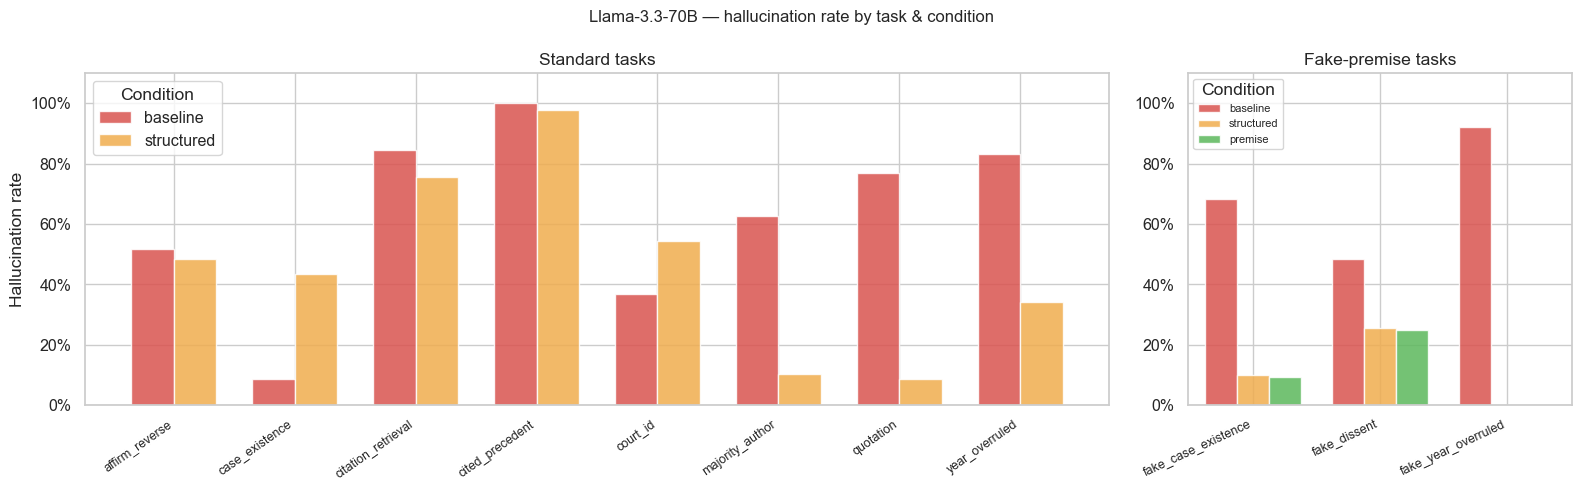

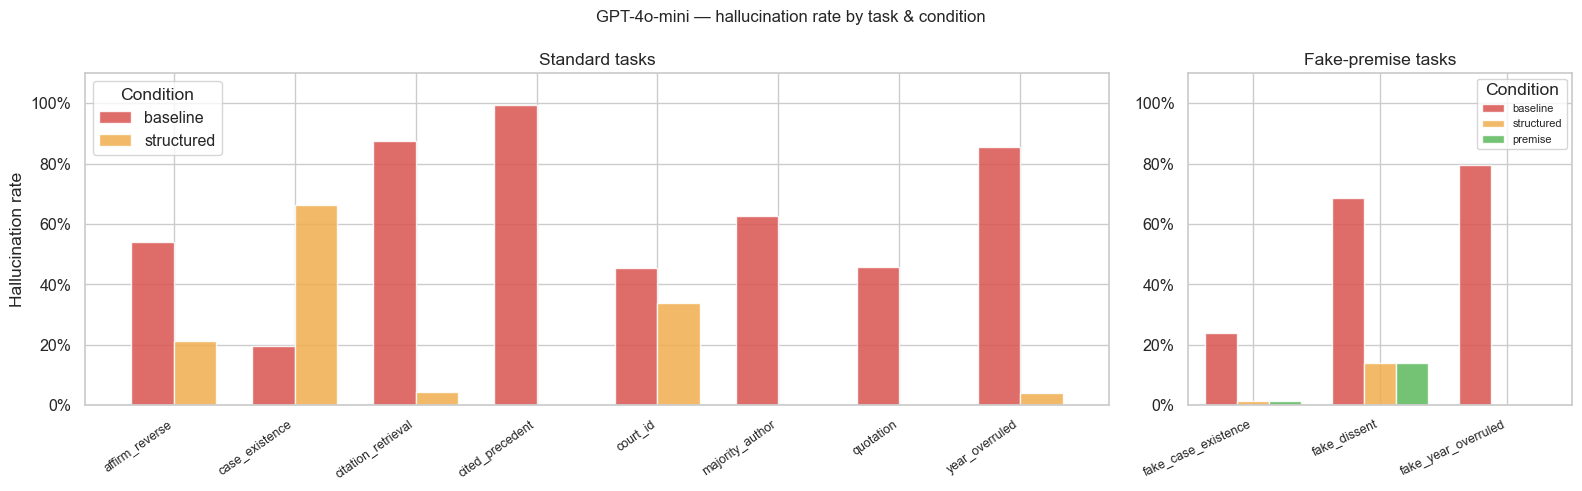

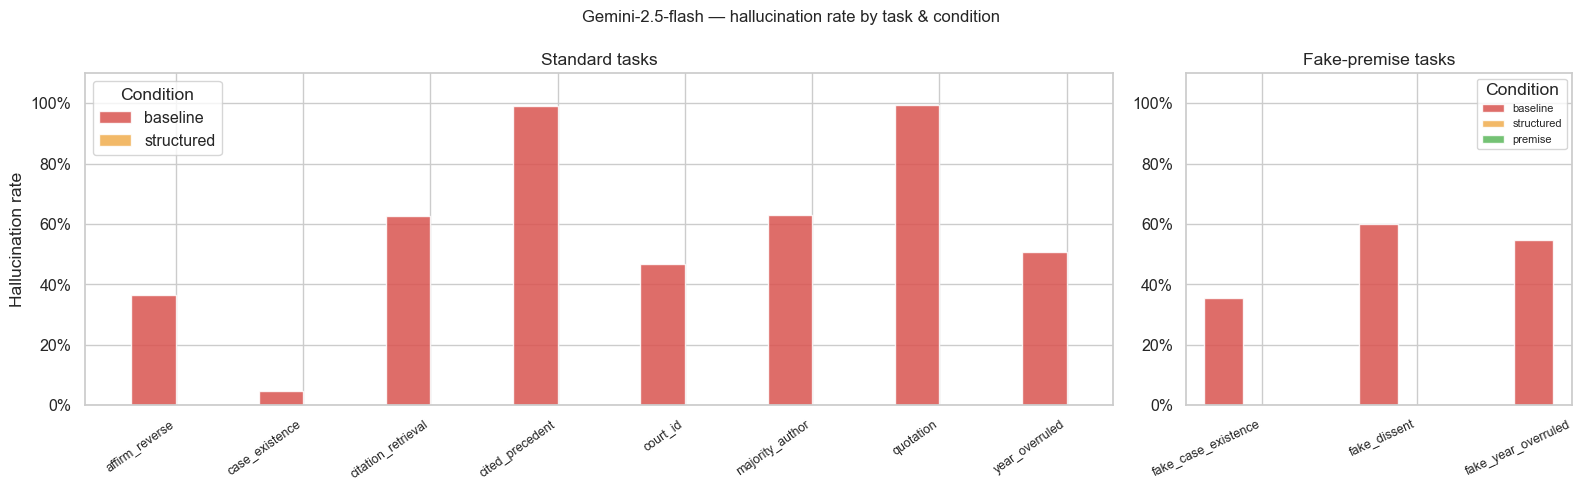

In [5]:
CONDITION_ORDER  = ["baseline", "structured", "premise"]
CONDITION_COLORS = {"baseline": "#d9534f", "structured": "#f0ad4e", "premise": "#5cb85c"}
available_models = [m for m in ["groq", "gpt4omini", "gemini"] if m in df["model_key"].unique()]

for model_key in available_models:
    sub = agg[agg["model_key"] == model_key]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                    gridspec_kw={"width_ratios": [8, 3]})

    # ── Left: standard tasks, baseline + structured ────────────────────────
    conds_std = ["baseline", "structured"]
    x_std = range(len(STANDARD_TASKS))
    width = 0.35
    for i, cond in enumerate(conds_std):
        vals = []
        for task in STANDARD_TASKS:
            row = sub[(sub["condition"] == cond) & (sub["task"] == task)]
            vals.append(row["hallucination_rate"].values[0] * 100 if len(row) else float("nan"))
        offset = (i - 0.5) * width
        ax1.bar([xi + offset for xi in x_std], vals, width,
                label=cond, color=CONDITION_COLORS[cond], alpha=0.85)
    ax1.set_xticks(list(x_std))
    ax1.set_xticklabels(STANDARD_TASKS, rotation=35, ha="right", fontsize=9)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.set_ylabel("Hallucination rate")
    ax1.set_title("Standard tasks")
    ax1.legend(title="Condition")
    ax1.set_ylim(0, 110)

    # ── Right: fake-premise tasks, all three conditions ────────────────────
    x_fake = range(len(FAKE_TASKS))
    width_f = 0.25
    for i, cond in enumerate(CONDITION_ORDER):
        vals = []
        for task in FAKE_TASKS:
            row = sub[(sub["condition"] == cond) & (sub["task"] == task)]
            vals.append(row["hallucination_rate"].values[0] * 100 if len(row) else float("nan"))
        offset = (i - 1) * width_f
        ax2.bar([xi + offset for xi in x_fake], vals, width_f,
                label=cond, color=CONDITION_COLORS[cond], alpha=0.85)
    ax2.set_xticks(list(x_fake))
    ax2.set_xticklabels(FAKE_TASKS, rotation=25, ha="right", fontsize=9)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_title("Fake-premise tasks")
    ax2.legend(title="Condition", fontsize=8)
    ax2.set_ylim(0, 110)

    fig.suptitle(f"{MODEL_LABELS[model_key]} — hallucination rate by task & condition", fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"hallucination_by_task_{model_key}.png", dpi=150)
    plt.show()

## 5 — Δ reduction heatmap (structured vs baseline)

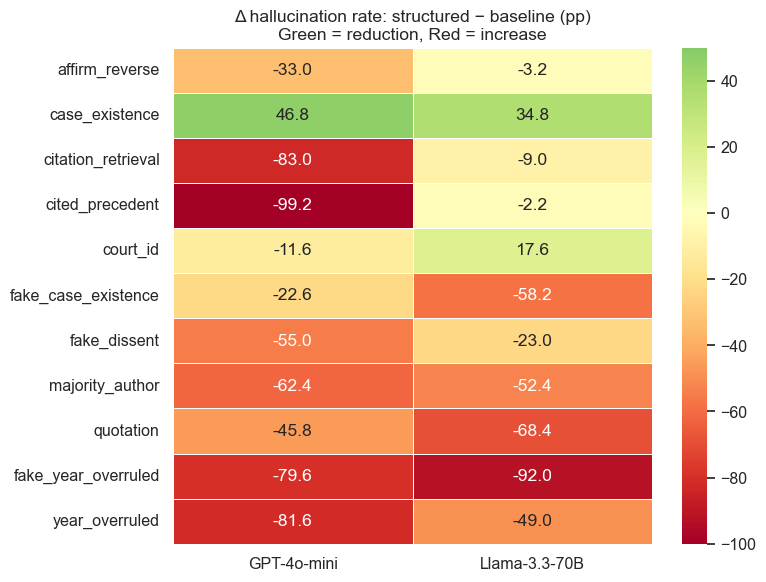

In [6]:
heat_data = delta[delta["condition"] == "structured"].pivot_table(
    index="task", columns="model", values="delta_pp"
).reindex(TASKS)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heat_data,
    annot=True, fmt=".1f", linewidths=0.5,
    cmap="RdYlGn", center=0, vmin=-100, vmax=50,
    ax=ax,
)
ax.set_title("Δ hallucination rate: structured − baseline (pp)\nGreen = reduction, Red = increase")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "delta_heatmap_structured.png", dpi=150)
plt.show()

## 6 — Premise vs structured vs baseline (fake_* tasks only)

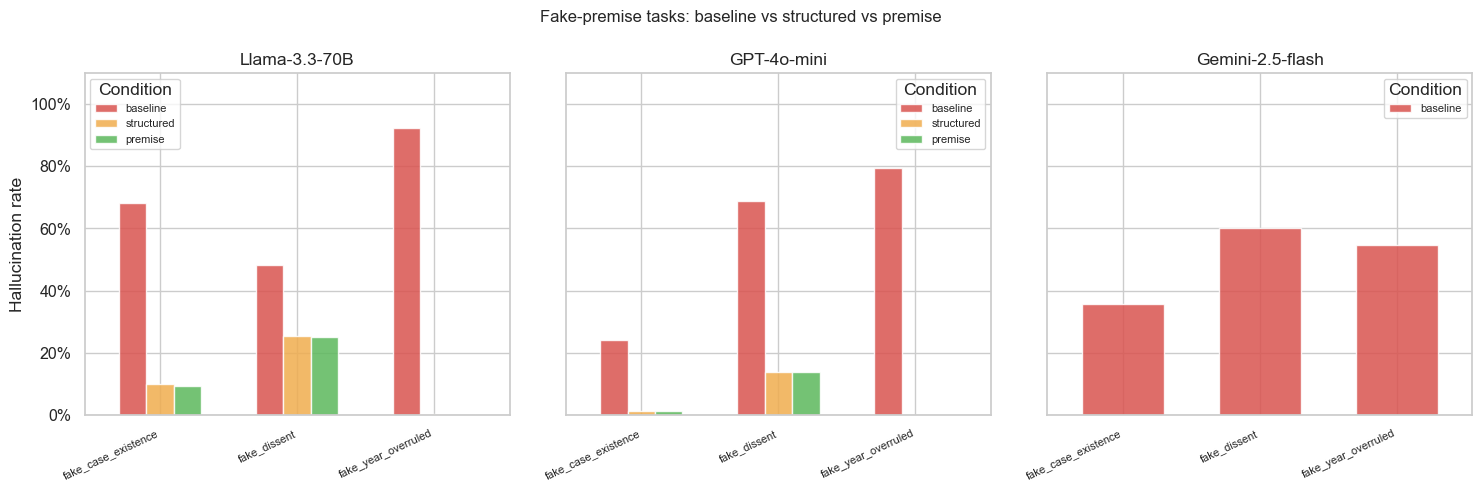

In [7]:
fake_df = agg[agg["task"].isin(FAKE_TASKS)].copy()

fig, axes = plt.subplots(1, len(available_models), figsize=(5 * len(available_models), 5), sharey=True)
if len(available_models) == 1:
    axes = [axes]

for ax, model_key in zip(axes, available_models):
    sub = fake_df[fake_df["model_key"] == model_key]
    plot_data = sub.pivot_table(index="task", columns="condition", values="hallucination_rate") * 100
    plot_data = plot_data.reindex(columns=[c for c in CONDITION_ORDER if c in plot_data.columns])
    plot_data.plot(kind="bar", ax=ax, color=[CONDITION_COLORS[c] for c in plot_data.columns],
                   alpha=0.85, width=0.6)
    ax.set_title(MODEL_LABELS[model_key])
    ax.set_xlabel("")
    ax.set_xticklabels(FAKE_TASKS, rotation=25, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 110)
    if ax == axes[0]:
        ax.set_ylabel("Hallucination rate")
    ax.legend(title="Condition", fontsize=8)

fig.suptitle("Fake-premise tasks: baseline vs structured vs premise", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fake_tasks_comparison.png", dpi=150)
plt.show()

## 7 — Overall hallucination rate & refusal rate summary

In [8]:
overall = (
    df.groupby(["condition", "model_key", "model"])
    .agg(
        n                  = ("hallucination", "count"),
        hallucination_rate = ("hallucination", "mean"),
        refusal_rate       = ("refusal", "mean"),
    )
    .reset_index()
)

# Add Δ vs baseline
base_overall = overall[overall["condition"] == "baseline"][["model_key", "hallucination_rate"]]
base_overall = base_overall.rename(columns={"hallucination_rate": "baseline_rate"})
overall = overall.merge(base_overall, on="model_key", how="left")
overall["delta_pp"] = (overall["hallucination_rate"] - overall["baseline_rate"]) * 100

display_cols = ["model", "condition", "n", "hallucination_rate", "refusal_rate", "delta_pp"]
fmt = {
    "hallucination_rate": "{:.1%}",
    "refusal_rate":       "{:.1%}",
    "delta_pp":           "{:+.1f}pp",
}
overall[display_cols].sort_values(["model", "condition"]) \
    .style.format(fmt, na_rep="—") \
    .background_gradient(subset=["hallucination_rate"], cmap="RdYlGn_r") \
    .background_gradient(subset=["delta_pp"], cmap="RdYlGn", vmin=-60, vmax=20)

,model,condition,n,hallucination_rate,refusal_rate,delta_pp
1,GPT-4o-mini,baseline,5500,61.1%,8.3%,+0.0pp
3,GPT-4o-mini,premise,1500,5.1%,0.0%,-56.1pp
5,GPT-4o-mini,structured,5500,13.2%,51.7%,-47.9pp
0,Gemini-2.5-flash,baseline,4955,55.6%,3.8%,+0.0pp
2,Llama-3.3-70B,baseline,5500,64.8%,6.0%,+0.0pp
4,Llama-3.3-70B,premise,1500,11.5%,6.2%,-53.4pp
6,Llama-3.3-70B,structured,5500,37.1%,25.3%,-27.7pp


## 8 — Refusal rate: did expansions increase abstention?

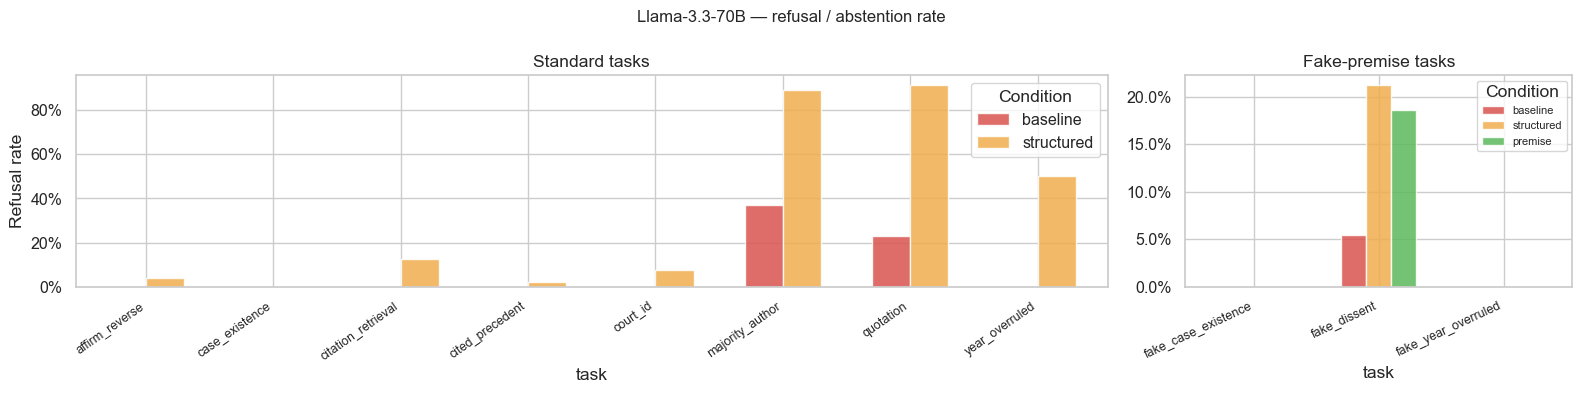

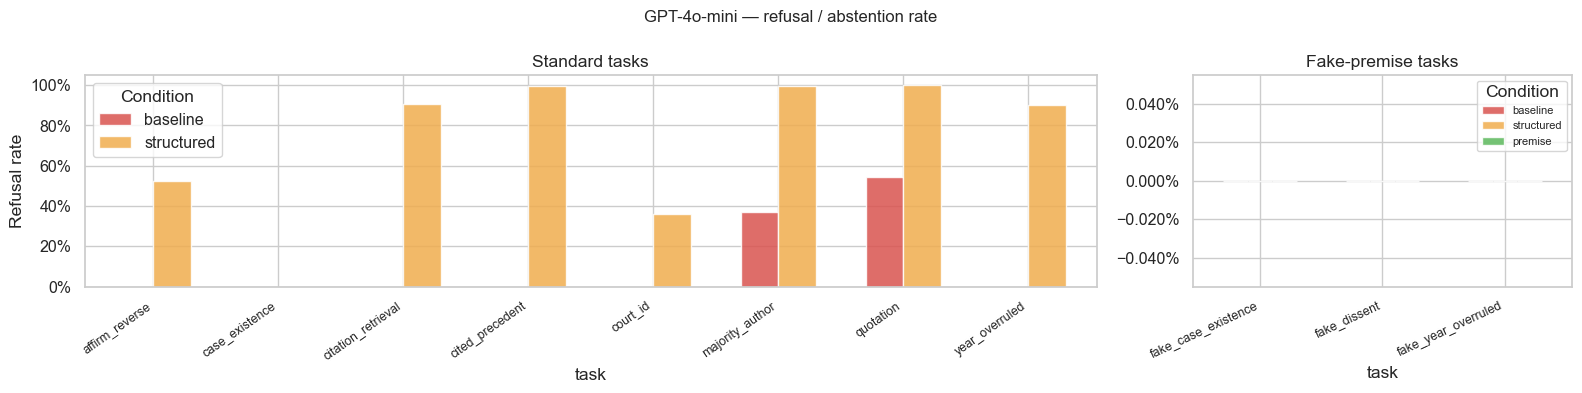

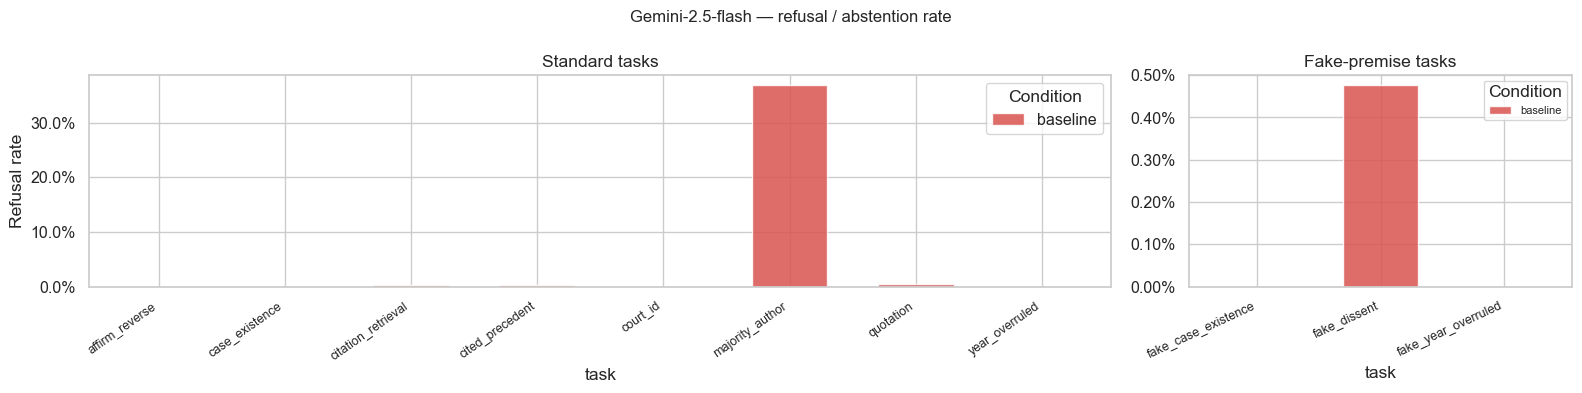

In [9]:
refusal_agg = (
    df.groupby(["condition", "model_key", "task"])["refusal"]
    .mean()
    .reset_index()
    .rename(columns={"refusal": "refusal_rate"})
)

for model_key in available_models:
    sub = refusal_agg[refusal_agg["model_key"] == model_key]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4),
                                    gridspec_kw={"width_ratios": [8, 3]})

    # ── Left: standard tasks, baseline + structured ────────────────────────
    rpivot_std = (
        sub[sub["task"].isin(STANDARD_TASKS) & sub["condition"].isin(["baseline", "structured"])]
        .pivot_table(index="task", columns="condition", values="refusal_rate") * 100
    ).reindex(STANDARD_TASKS)
    rpivot_std.plot(kind="bar", ax=ax1,
                    color=[CONDITION_COLORS[c] for c in rpivot_std.columns],
                    alpha=0.85, width=0.6)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.set_title("Standard tasks")
    ax1.set_xticklabels(STANDARD_TASKS, rotation=35, ha="right", fontsize=9)
    ax1.set_ylabel("Refusal rate")
    ax1.legend(title="Condition")

    # ── Right: fake-premise tasks, all three conditions ────────────────────
    rpivot_fake = (
        sub[sub["task"].isin(FAKE_TASKS)]
        .pivot_table(index="task", columns="condition", values="refusal_rate") * 100
    ).reindex(FAKE_TASKS)
    rpivot_fake = rpivot_fake.reindex(
        columns=[c for c in CONDITION_ORDER if c in rpivot_fake.columns]
    )
    rpivot_fake.plot(kind="bar", ax=ax2,
                     color=[CONDITION_COLORS[c] for c in rpivot_fake.columns],
                     alpha=0.85, width=0.6)
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.set_title("Fake-premise tasks")
    ax2.set_xticklabels(FAKE_TASKS, rotation=25, ha="right", fontsize=9)
    ax2.legend(title="Condition", fontsize=8)

    fig.suptitle(f"{MODEL_LABELS[model_key]} — refusal / abstention rate", fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"refusal_rate_{model_key}.png", dpi=150)
    plt.show()

## 9 — Export full aggregated table

In [10]:
agg.to_csv(RESULTS_DIR / "hallucination_rates.csv", index=False)
print(f"Saved {len(agg)} rows to results/hallucination_rates.csv")
agg

Saved 61 rows to results/hallucination_rates.csv


,condition,model_key,model,task,n,hallucination_rate,refusal_rate,mean_score
0,baseline,gemini,Gemini-2.5-flash,affirm_reverse,500,0.364,0.000,63.6
1,baseline,gemini,Gemini-2.5-flash,case_existence,500,0.046,0.000,95.4
2,baseline,gemini,Gemini-2.5-flash,citation_retrieval,500,0.628,0.002,68.4
3,baseline,gemini,Gemini-2.5-flash,cited_precedent,500,0.992,0.002,25.9
4,baseline,gemini,Gemini-2.5-flash,court_id,500,0.468,0.000,73.9
...,...,...,...,...,...,...,...,...
56,structured,groq,Llama-3.3-70B,fake_dissent,500,0.254,0.212,67.8
57,structured,groq,Llama-3.3-70B,fake_year_overruled,500,0.002,0.000,99.8
58,structured,groq,Llama-3.3-70B,majority_author,500,0.102,0.892,28.4
59,structured,groq,Llama-3.3-70B,quotation,500,0.086,0.914,33.0
